**Task** **2** : **Speech** **Emotion** **Recognition**

**RAVDESS** **Dataset**

In [ ]:
# Install Libraries

!pip install -q librosa soundfile

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import librosa
import librosa.display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow:", tf.__version__)
print("Librosa:", librosa.__version__)

TensorFlow: 2.20.0
Librosa: 0.11.0


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive.zip


In [ ]:
import zipfile

# Extract the Dataset

zip_file = "archive.zip"

extract_path = "/content/RAVDESS"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("RAVDESS dataset extracted successfully!")

RAVDESS dataset extracted successfully!


In [ ]:
import os

# Check the Folders

print(os.listdir(extract_path)[:10])

['Actor_03', 'Actor_15', 'Actor_19', 'Actor_22', 'Actor_07', 'Actor_10', 'Actor_18', 'Actor_04', 'Actor_06', 'Actor_13']


In [ ]:
import glob

audio_files = glob.glob(
    "/content/RAVDESS/**/*.wav",
    recursive=True
)

print("Total WAV files:", len(audio_files))

Total WAV files: 2880


In [ ]:
# Mapping Emotions

emotion_map = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

In [ ]:
# Extract Information From Filename

def get_ravdess_information(file_path):

    filename = os.path.basename(file_path)

    parts = filename.replace('.wav', '').split('-')

    modality = parts[0]
    vocal_channel = parts[1]
    emotion_code = parts[2]
    intensity = parts[3]
    statement = parts[4]
    repetition = parts[5]
    actor = parts[6]

    emotion = emotion_map.get(emotion_code)

    return {
        'file': file_path,
        'emotion': emotion,
        'emotion_code': emotion_code,
        'actor': int(actor),
        'vocal_channel': vocal_channel,
        'intensity': intensity
    }

In [ ]:
# Create DataFrame

data = []

for file in audio_files:

    info = get_ravdess_information(file)

    # Use speech only
    if info['vocal_channel'] == '01':

        data.append(info)

ravdess_df = pd.DataFrame(data)

print("Number of speech files:", len(ravdess_df))

display(ravdess_df.head())

Number of speech files: 2880


,file,emotion,emotion_code,actor,vocal_channel,intensity
0,/content/RAVDESS/Actor_03/03-01-04-02-02-01-03...,sad,04,3,01,02
1,/content/RAVDESS/Actor_03/03-01-02-02-02-01-03...,calm,02,3,01,02
2,/content/RAVDESS/Actor_03/03-01-03-02-01-02-03...,happy,03,3,01,02
3,/content/RAVDESS/Actor_03/03-01-08-02-02-02-03...,surprised,08,3,01,02
4,/content/RAVDESS/Actor_03/03-01-05-01-01-01-03...,angry,05,3,01,01


In [ ]:
# Check Dataset Information

print("Dataset Shape:")
print(ravdess_df.shape)

print("\nColumns:")
print(ravdess_df.columns.tolist())

print("\nEmotion Classes:")
print(ravdess_df['emotion'].unique())

Dataset Shape:
(2880, 6)

Columns:
['file', 'emotion', 'emotion_code', 'actor', 'vocal_channel', 'intensity']

Emotion Classes:
['sad' 'calm' 'happy' 'surprised' 'angry' 'disgust' 'fearful' 'neutral']


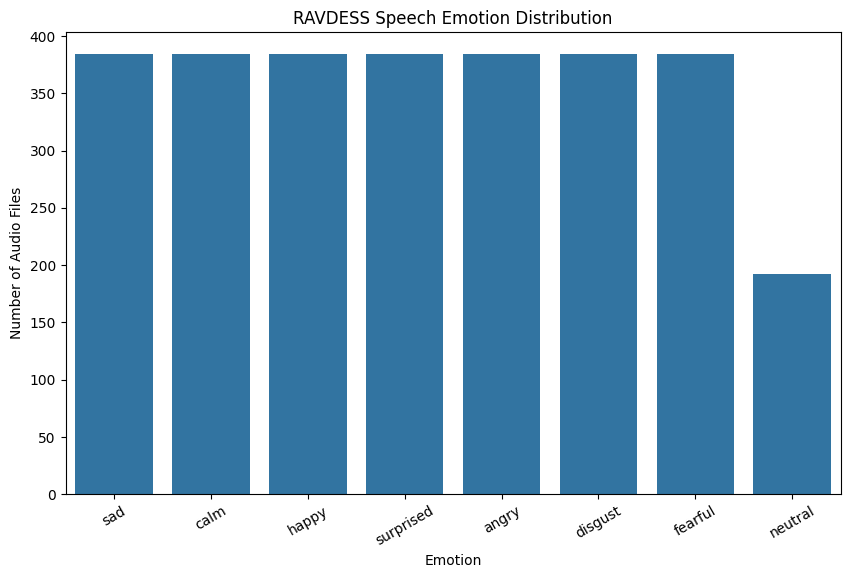

In [ ]:
# Emotion Distrubution

plt.figure(figsize=(10, 6))

sns.countplot(
    data=ravdess_df,
    x='emotion'
)

plt.title(
    'RAVDESS Speech Emotion Distribution'
)

plt.xlabel('Emotion')
plt.ylabel('Number of Audio Files')

plt.xticks(rotation=30)

plt.show()

In [ ]:
# Emotion Count

print(
    ravdess_df['emotion'].value_counts()
)

emotion
sad          384
calm         384
happy        384
surprised    384
angry        384
disgust      384
fearful      384
neutral      192
Name: count, dtype: int64


In [ ]:
# Play an Audio File

from IPython.display import Audio, display

sample_file = ravdess_df.iloc[0]['file']

print(
    "Emotion:",
    ravdess_df.iloc[0]['emotion']
)

display(
    Audio(sample_file)
)

Emotion: sad


In [ ]:
# Load Audio

sample_audio, sample_rate = librosa.load(
    sample_file,
    sr=None
)

print("Sample Rate:", sample_rate)
print("Number of Samples:", len(sample_audio))
print(
    "Duration:",
    round(len(sample_audio) / sample_rate, 2),
    "seconds"
)

Sample Rate: 48000
Number of Samples: 166566
Duration: 3.47 seconds


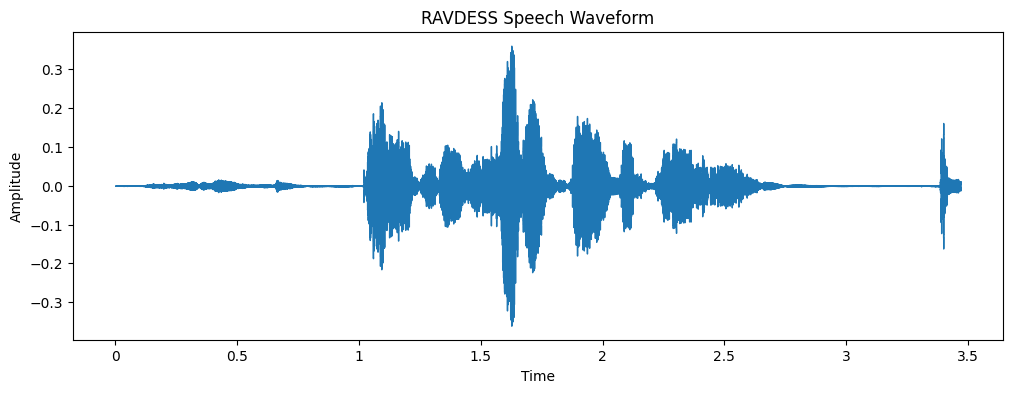

In [ ]:
# Display Waveform

plt.figure(figsize=(12, 4))

librosa.display.waveshow(
    sample_audio,
    sr=sample_rate
)

plt.title(
    "RAVDESS Speech Waveform"
)

plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.show()

In [ ]:
# Extract MFCC Features

def extract_mfcc(
    file_path,
    max_len=174
):

    audio, sr = librosa.load(
        file_path,
        sr=22050
    )

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=40
    )

    # Make every audio file the same size

    if mfcc.shape[1] < max_len:

        pad_width = max_len - mfcc.shape[1]

        mfcc = np.pad(
            mfcc,
            ((0, 0), (0, pad_width)),
            mode='constant'
        )

    else:

        mfcc = mfcc[:, :max_len]

    return mfcc

In [ ]:
# Test MFCC Extraction

test_mfcc = extract_mfcc(
    sample_file
)

print(
    "MFCC Shape:",
    test_mfcc.shape
)

MFCC Shape: (40, 174)


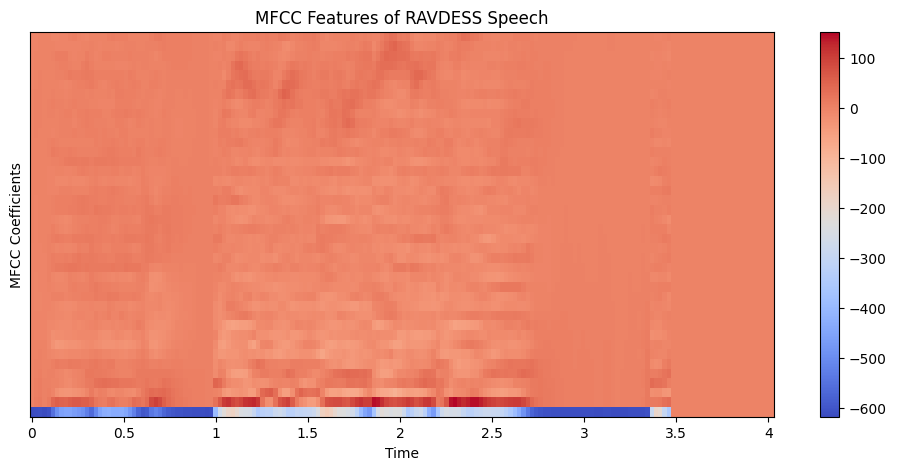

In [ ]:
# Display

plt.figure(figsize=(12, 5))

librosa.display.specshow(
    test_mfcc,
    x_axis='time',
    sr=22050
)

plt.colorbar()

plt.title(
    "MFCC Features of RAVDESS Speech"
)

plt.xlabel("Time")

plt.ylabel("MFCC Coefficients")

plt.show()

In [ ]:
# Extract Features From All Audio

X = []
y = []

for index, row in ravdess_df.iterrows():

    try:

        mfcc = extract_mfcc(
            row['file']
        )

        X.append(mfcc)

        y.append(
            row['emotion']
        )

    except Exception as e:

        print(
            "Error processing:",
            row['file']
        )

        print(e)

In [ ]:
# Convert to numpy

X = np.array(X)
y = np.array(y)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (2880, 40, 174)
y Shape: (2880,)


In [ ]:
# Reshape For CNN

X = X[..., np.newaxis]

print(
    "Final X Shape:",
    X.shape
)

Final X Shape: (2880, 40, 174, 1)


In [ ]:
# Encode Emotions Label

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print(
    "Emotion Classes:"
)

print(
    label_encoder.classes_
)

Emotion Classes:
['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


In [ ]:
# No Of class
num_classes = len(
    label_encoder.classes_
)

print(
    "Number of classes:",
    num_classes
)

Number of classes: 8


In [ ]:
# convert Label to categorical

y_categorical = tf.keras.utils.to_categorical(
    y_encoded,
    num_classes=num_classes
)

print(
    y_categorical.shape
)

(2880, 8)


In [ ]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y_categorical,

    test_size=0.20,

    random_state=42,

    stratify=y_encoded
)

print(
    "Training samples:",
    X_train.shape[0]
)

print(
    "Testing samples:",
    X_test.shape[0]
)

Training samples: 2304
Testing samples: 576


In [ ]:
# Build CNN Model

model = Sequential([

    Conv2D(
        32,
        (3, 3),
        activation='relu',
        input_shape=X_train.shape[1:]
    ),

    BatchNormalization(),

    MaxPooling2D(
        (2, 2)
    ),

    Conv2D(
        64,
        (3, 3),
        activation='relu'
    ),

    BatchNormalization(),

    MaxPooling2D(
        (2, 2)
    ),

    Conv2D(
        128,
        (3, 3),
        activation='relu'
    ),

    BatchNormalization(),

    MaxPooling2D(
        (2, 2)
    ),

    Flatten(),

    Dense(
        256,
        activation='relu'
    ),

    Dropout(0.4),

    Dense(
        num_classes,
        activation='softmax'
    )
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 38, 172, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 38, 172, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 19, 86, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 17, 84, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 17, 84, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 42, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 6, 40, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 6, 40, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 20, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7680)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,966,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,061,960 (7.87 MB)

 Trainable params: 2,061,512 (7.86 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# Compile

model.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

In [ ]:
# Early Stopping

early_stopping = EarlyStopping(

    monitor='val_loss',

    patience=5,

    restore_best_weights=True
)

In [ ]:
# Train the Model

history = model.fit(

    X_train,

    y_train,

    validation_split=0.15,

    epochs=4,

    batch_size=32,

    callbacks=[
        early_stopping
    ]
)

Epoch 1/4
62/62 ━━━━━━━━━━━━━━━━━━━━ 19s 303ms/step - accuracy: 0.3069 - loss: 1.8306 - val_accuracy: 0.3237 - val_loss: 1.7315
Epoch 2/4
62/62 ━━━━━━━━━━━━━━━━━━━━ 20s 322ms/step - accuracy: 0.3539 - loss: 1.6104 - val_accuracy: 0.4191 - val_loss: 1.5948
Epoch 3/4
62/62 ━━━━━━━━━━━━━━━━━━━━ 19s 297ms/step - accuracy: 0.4321 - loss: 1.4921 - val_accuracy: 0.4480 - val_loss: 1.4135
Epoch 4/4
62/62 ━━━━━━━━━━━━━━━━━━━━ 19s 306ms/step - accuracy: 0.4852 - loss: 1.2925 - val_accuracy: 0.5318 - val_loss: 1.2993


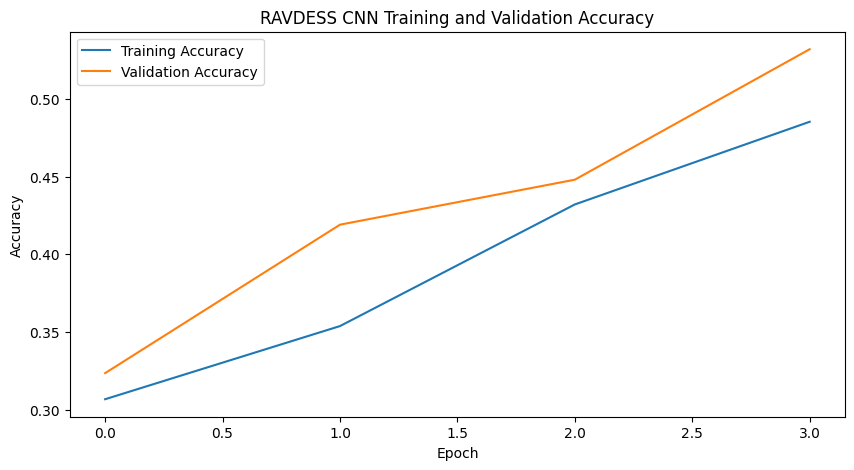

In [ ]:
# Accuracy Graph

plt.figure(figsize=(10, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title(
    'RAVDESS CNN Training and Validation Accuracy'
)

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend()

plt.show()

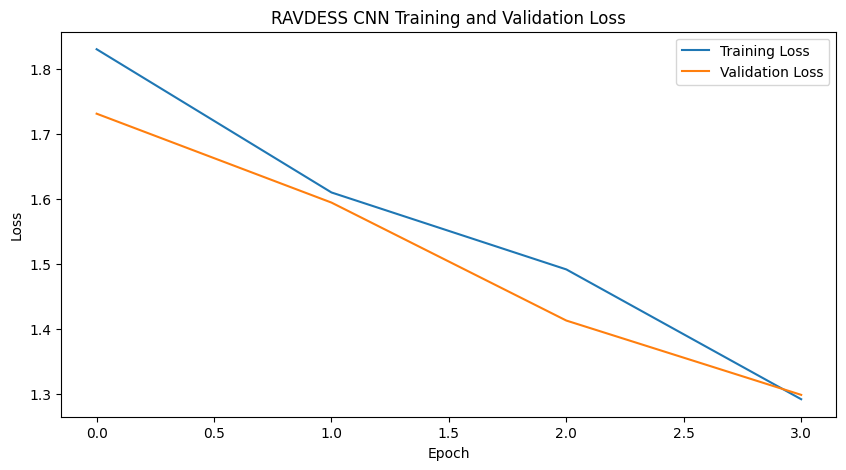

In [ ]:
# Loss Graph

plt.figure(figsize=(10, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title(
    'RAVDESS CNN Training and Validation Loss'
)

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

plt.show()

In [ ]:
# Evaluate the Model

test_loss, test_accuracy = model.evaluate(

    X_test,

    y_test,

    verbose=1
)

print(
    "Test Loss:",
    test_loss
)

print(
    "Test Accuracy:",
    test_accuracy
)

print(
    "Test Accuracy Percentage:",
    round(test_accuracy * 100, 2),
    "%"
)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.5660 - loss: 1.2885
Test Loss: 1.2885422706604004
Test Accuracy: 0.5659722089767456
Test Accuracy Percentage: 56.6 %


In [ ]:
# Genrate Predictions

predictions = model.predict(
    X_test
)

predicted_classes = np.argmax(
    predictions,
    axis=1
)

actual_classes = np.argmax(
    y_test,
    axis=1
)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step


In [ ]:
# Classfication Report

print(
    classification_report(

        actual_classes,

        predicted_classes,

        target_names=
        label_encoder.classes_
    )
)

              precision    recall  f1-score   support

       angry       0.91      0.55      0.69        76
        calm       0.49      0.86      0.62        77
     disgust       0.56      0.64      0.60        77
     fearful       0.59      0.64      0.61        77
       happy       0.77      0.22      0.34        77
     neutral       0.50      0.29      0.37        38
         sad       0.31      0.39      0.35        77
   surprised       0.74      0.81      0.77        77

    accuracy                           0.57       576
   macro avg       0.61      0.55      0.54       576
weighted avg       0.62      0.57      0.55       576



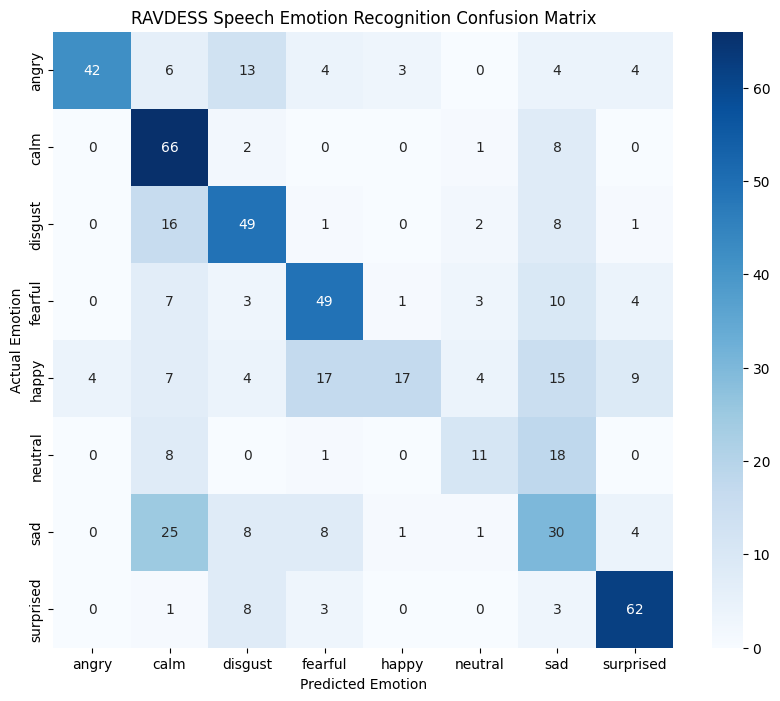

In [ ]:
# Confusion Matrix

cm = confusion_matrix(

    actual_classes,

    predicted_classes
)

plt.figure(figsize=(10, 8))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=
    label_encoder.classes_,

    yticklabels=
    label_encoder.classes_
)

plt.title(
    'RAVDESS Speech Emotion Recognition Confusion Matrix'
)

plt.xlabel(
    'Predicted Emotion'
)

plt.ylabel(
    'Actual Emotion'
)

plt.show()

**Show** **Actual** **Vs** **Predited** **Emotions**

In [ ]:
results = pd.DataFrame({

    'Actual': label_encoder.inverse_transform(
        actual_classes
    ),

    'Predicted': label_encoder.inverse_transform(
        predicted_classes
    )
})

display(
    results.head(20)
)

,Actual,Predicted
0,happy,neutral
1,sad,calm
2,calm,calm
3,happy,sad
4,disgust,calm
5,sad,sad
6,angry,angry
7,happy,fearful
8,calm,calm
9,calm,calm


**Test** **a** **Single** **Audio** **File**

In [ ]:
def predict_emotion(
    file_path
):

    mfcc = extract_mfcc(
        file_path
    )

    mfcc = mfcc[np.newaxis, ...]

    mfcc = mfcc[..., np.newaxis]

    prediction = model.predict(
        mfcc,
        verbose=0
    )[0]

    predicted_index = np.argmax(
        prediction
    )

    emotion = label_encoder.classes_[
        predicted_index
    ]

    confidence = prediction[
        predicted_index
    ]

    return emotion, confidence

In [ ]:
# Test Prediction

test_file = ravdess_df.iloc[100]['file']

actual_emotion = ravdess_df.iloc[100]['emotion']

predicted_emotion, confidence = predict_emotion(
    test_file
)

print(
    "Actual Emotion:",
    actual_emotion
)

print(
    "Predicted Emotion:",
    predicted_emotion
)

print(
    "Confidence:",
    round(confidence * 100, 2),
    "%"
)

Actual Emotion: calm
Predicted Emotion: calm
Confidence: 93.95 %


In [ ]:
# Play the same audio

print(
    "Actual Emotion:",
    actual_emotion
)

print(
    "Predicted Emotion:",
    predicted_emotion
)

display(
    Audio(test_file)
)


Actual Emotion: calm
Predicted Emotion: calm


In [ ]:
# save the model

model.save(
    "RAVDESS_Speech_Emotion_CNN.keras"
)

print(
    "Model saved successfully!"
)

Model saved successfully!


In [ ]:
# save label Encoder

import pickle

with open(
    "emotion_label_encoder.pkl",
    "wb"
) as file:

    pickle.dump(
        label_encoder,
        file
    )

print(
    "Label encoder saved!"
)

Label encoder saved!


In [ ]:
# Install require Libraries

!pip install -q librosa soundfile

In [ ]:
import os
import zipfile
import glob
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import librosa
import librosa.display

from IPython.display import Audio, display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow:", tf.__version__)
print("Librosa:", librosa.__version__)

TensorFlow: 2.20.0
Librosa: 0.11.0


**Use** **EMO**-**DB** **Dataset**

In [ ]:
# Upload Dataset

uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [ ]:
# Extract datset

zip_file = "archive (1).zip"

extract_path = "/content/EMO-DB"

with zipfile.ZipFile(
    zip_file,
    'r'
) as zip_ref:

    zip_ref.extractall(
        extract_path
    )

print("EMO-DB extracted successfully!")

EMO-DB extracted successfully!


In [ ]:
!find /content/EMO-DB -type f | head -20

/content/EMO-DB/wav/11b01Fc.wav
/content/EMO-DB/wav/08a07Fd.wav
/content/EMO-DB/wav/08b10Wa.wav
/content/EMO-DB/wav/03a02Fc.wav
/content/EMO-DB/wav/09b10Wa.wav
/content/EMO-DB/wav/12a02Wc.wav
/content/EMO-DB/wav/12b03Ta.wav
/content/EMO-DB/wav/14a04Wb.wav
/content/EMO-DB/wav/10a07Ta.wav
/content/EMO-DB/wav/14b02Wd.wav
/content/EMO-DB/wav/08b02Tc.wav
/content/EMO-DB/wav/13b02Wa.wav
/content/EMO-DB/wav/16b09La.wav
/content/EMO-DB/wav/03b01Td.wav
/content/EMO-DB/wav/13a01Nb.wav
/content/EMO-DB/wav/08b09Lc.wav
/content/EMO-DB/wav/16b01Wb.wav
/content/EMO-DB/wav/08a05Fe.wav
/content/EMO-DB/wav/13a07Fd.wav
/content/EMO-DB/wav/13b01Wa.wav


In [ ]:
# Find All wav Files

audio_files = glob.glob(
    "/content/EMO-DB/**/*.wav",
    recursive=True
)

print(
    "Total audio files:",
    len(audio_files)
)

Total audio files: 535


In [ ]:
# Emotion Map

emotion_map = {
    'W': 'angry',
    'L': 'boredom',
    'E': 'disgust',
    'A': 'fear',
    'F': 'happy',
    'T': 'sad',
    'N': 'neutral'
}

In [ ]:
# Extract Emotion From Filename

def get_emodb_emotion(file_path):

    filename = os.path.basename(
        file_path
    )

    # Remove extension
    filename = os.path.splitext(
        filename
    )[0]

    # Emotion is the 6th character
    emotion_code = filename[5].upper()

    return emotion_map.get(
        emotion_code
    )

In [ ]:
print(
    get_emodb_emotion(
        audio_files[0]
    )
)

happy


In [ ]:
# Create Dataframe

data = []

for file in audio_files:

    emotion = get_emodb_emotion(
        file
    )

    if emotion is not None:

        data.append({
            'file': file,
            'emotion': emotion
        })

emodb_df = pd.DataFrame(
    data
)

print(
    "Dataset shape:",
    emodb_df.shape
)

display(
    emodb_df.head(10)
)

Dataset shape: (535, 2)


,file,emotion
0,/content/EMO-DB/wav/11b01Fc.wav,happy
1,/content/EMO-DB/wav/08a07Fd.wav,happy
2,/content/EMO-DB/wav/08b10Wa.wav,angry
3,/content/EMO-DB/wav/03a02Fc.wav,happy
4,/content/EMO-DB/wav/09b10Wa.wav,angry
5,/content/EMO-DB/wav/12a02Wc.wav,angry
6,/content/EMO-DB/wav/12b03Ta.wav,sad
7,/content/EMO-DB/wav/14a04Wb.wav,angry
8,/content/EMO-DB/wav/10a07Ta.wav,sad
9,/content/EMO-DB/wav/14b02Wd.wav,angry


In [ ]:
# Check Emtion Classes

print(
    emodb_df['emotion'].unique()
)

print(
    emodb_df['emotion'].value_counts()
)

['happy' 'angry' 'sad' 'boredom' 'neutral' 'fear' 'disgust']
emotion
angry      127
boredom     81
neutral     79
happy       71
fear        69
sad         62
disgust     46
Name: count, dtype: int64


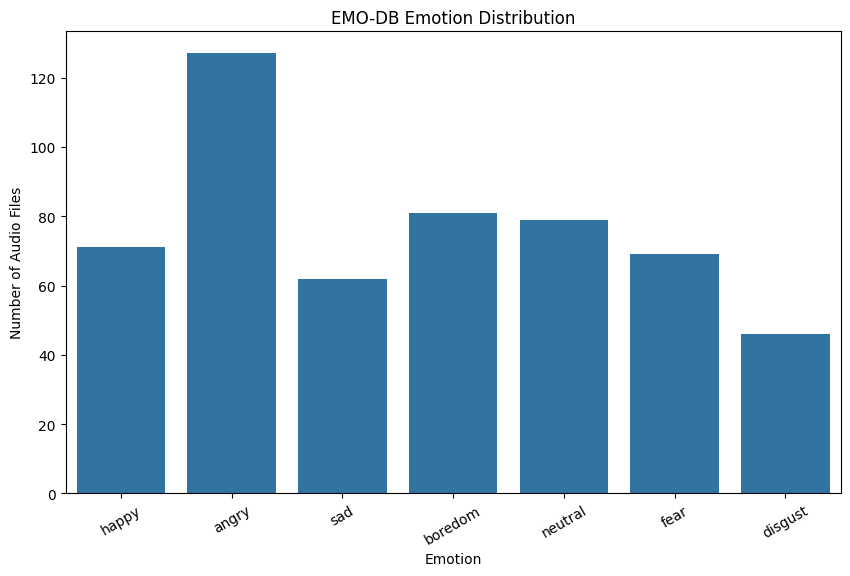

In [ ]:
# Visulize  Emotions Distrubutions

plt.figure(figsize=(10, 6))

sns.countplot(
    data=emodb_df,
    x='emotion'
)

plt.title(
    'EMO-DB Emotion Distribution'
)

plt.xlabel(
    'Emotion'
)

plt.ylabel(
    'Number of Audio Files'
)

plt.xticks(
    rotation=30
)

plt.show()

In [ ]:
# Play An Audio file

sample_file = emodb_df.iloc[0]['file']

print(
    "File:",
    sample_file
)

print(
    "Emotion:",
    emodb_df.iloc[0]['emotion']
)

display(
    Audio(sample_file)
)

File: /content/EMO-DB/wav/11b01Fc.wav
Emotion: happy


In [ ]:
# Load audio

audio, sr = librosa.load(
    sample_file,
    sr=None
)

print(
    "Sample Rate:",
    sr
)

print(
    "Number of Samples:",
    len(audio)
)

print(
    "Duration:",
    round(
        len(audio) / sr,
        2
    ),
    "seconds"
)

Sample Rate: 16000
Number of Samples: 40879
Duration: 2.55 seconds


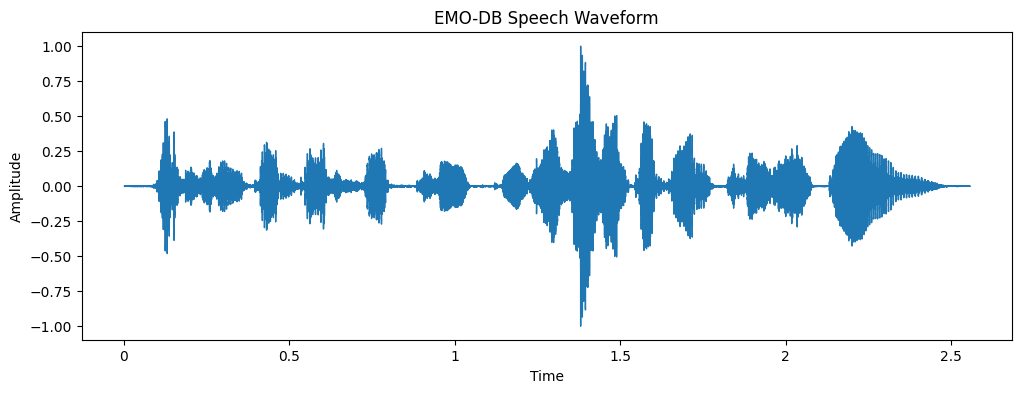

In [ ]:
# Display Audio WaveForm

plt.figure(figsize=(12, 4))

librosa.display.waveshow(
    audio,
    sr=sr
)

plt.title(
    "EMO-DB Speech Waveform"
)

plt.xlabel(
    "Time"
)

plt.ylabel(
    "Amplitude"
)

plt.show()

In [ ]:
# Extract MFCC Features

def extract_mfcc(
    file_path,
    max_len=174
):

    audio, sr = librosa.load(
        file_path,
        sr=22050
    )

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=40
    )

    # Padding
    if mfcc.shape[1] < max_len:

        pad_width = (
            max_len -
            mfcc.shape[1]
        )

        mfcc = np.pad(
            mfcc,
            (
                (0, 0),
                (0, pad_width)
            ),
            mode='constant'
        )

    # Truncation
    else:

        mfcc = mfcc[
            :, :max_len
        ]

    return mfcc

In [ ]:
# Test Extraction

test_mfcc = extract_mfcc(
    sample_file
)

print(
    "MFCC shape:",
    test_mfcc.shape
)

MFCC shape: (40, 174)


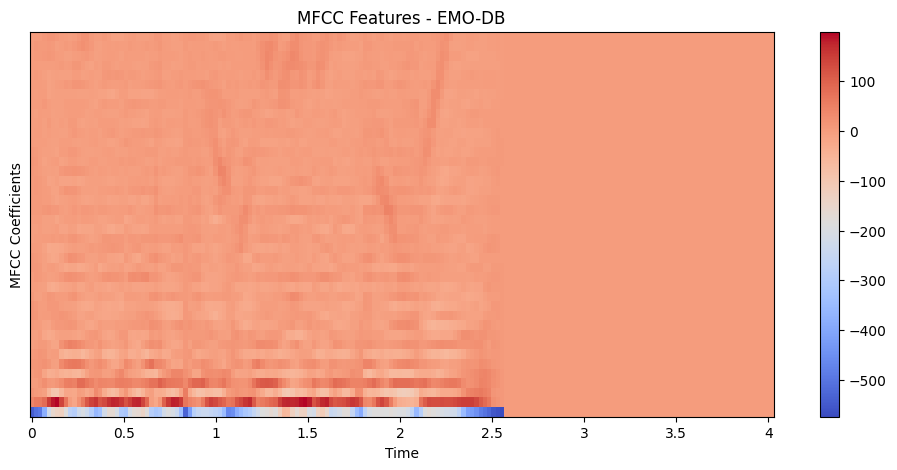

In [ ]:
# Display

plt.figure(figsize=(12, 5))

librosa.display.specshow(
    test_mfcc,
    x_axis='time',
    sr=22050
)

plt.colorbar()

plt.title(
    "MFCC Features - EMO-DB"
)

plt.xlabel(
    "Time"
)

plt.ylabel(
    "MFCC Coefficients"
)

plt.show()

In [ ]:
# Mel Spectrogram

audio, sr = librosa.load(
    sample_file,
    sr=22050
)

mel = librosa.feature.melspectrogram(
    y=audio,
    sr=sr
)

mel_db = librosa.power_to_db(
    mel,
    ref=np.max
)

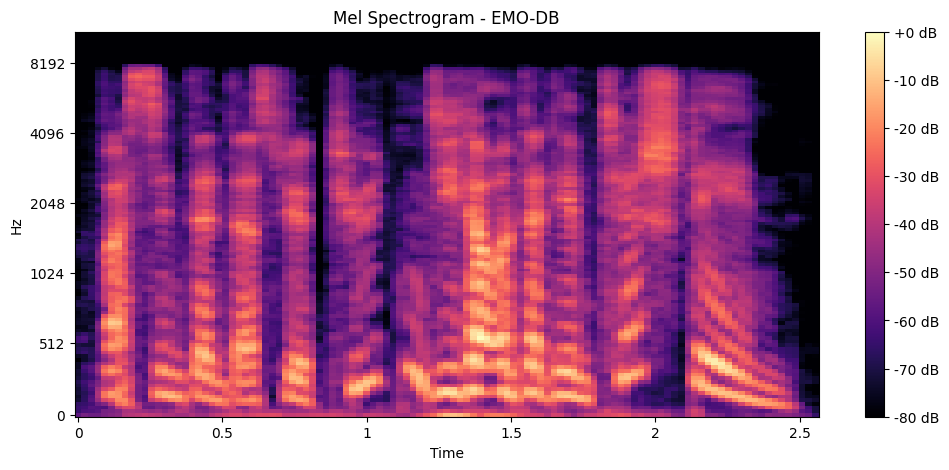

In [ ]:
# Display

plt.figure(figsize=(12, 5))

librosa.display.specshow(
    mel_db,
    x_axis='time',
    y_axis='mel',
    sr=sr
)

plt.colorbar(
    format='%+2.0f dB'
)

plt.title(
    "Mel Spectrogram - EMO-DB"
)

plt.show()

In [ ]:
# Extract MFCC From All Files

X = []
y = []

for index, row in emodb_df.iterrows():

    try:

        mfcc = extract_mfcc(
            row['file']
        )

        X.append(
            mfcc
        )

        y.append(
            row['emotion']
        )

    except Exception as e:

        print(
            "Error processing:",
            row['file']
        )

        print(e)

In [ ]:
# Convert into Numpy

X = np.array(X)
y = np.array(y)

print(
    "X shape:",
    X.shape
)

print(
    "y shape:",
    y.shape
)

X shape: (535, 40, 174)
y shape: (535,)


In [ ]:
# ADD CNN Channel

X = X[..., np.newaxis]

print(
    "Final X shape:",
    X.shape
)

Final X shape: (535, 40, 174, 1)


In [ ]:
# Encode Emotions label

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(
    y
)

print(
    "Encoded Classes:"
)

print(
    label_encoder.classes_
)

# No of classes

num_classes = len(
    label_encoder.classes_
)

print(
    "Number of classes:",
    num_classes
)

Encoded Classes:
['angry' 'boredom' 'disgust' 'fear' 'happy' 'neutral' 'sad']
Number of classes: 7


In [ ]:
# one hot Encoding

y_categorical = tf.keras.utils.to_categorical(
    y_encoded,
    num_classes
)

print(
    y_categorical.shape
)

(535, 7)


In [ ]:
# train-test split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y_categorical,

    test_size=0.20,

    random_state=42,

    stratify=y_encoded
)

In [ ]:
# check

print(
    "Training samples:",
    X_train.shape[0]
)

print(
    "Testing samples:",
    X_test.shape[0]
)

Training samples: 428
Testing samples: 107


In [ ]:
# Build CNN Model

model = Sequential([

    Conv2D(
        32,
        (3, 3),
        activation='relu',
        input_shape=X_train.shape[1:]
    ),

    BatchNormalization(),

    MaxPooling2D(
        (2, 2)
    ),

    Conv2D(
        64,
        (3, 3),
        activation='relu'
    ),

    BatchNormalization(),

    MaxPooling2D(
        (2, 2)
    ),

    Conv2D(
        128,
        (3, 3),
        activation='relu'
    ),

    BatchNormalization(),

    MaxPooling2D(
        (2, 2)
    ),

    Flatten(),

    Dense(
        256,
        activation='relu'
    ),

    Dropout(0.4),

    Dense(
        num_classes,
        activation='softmax'
    )
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 38, 172, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 38, 172, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 19, 86, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 17, 84, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 17, 84, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 42, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 6, 40, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 6, 40, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 3, 20, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 7680)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     1,966,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,061,703 (7.86 MB)

 Trainable params: 2,061,255 (7.86 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# Compile

model.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

In [ ]:
# Eraly stopping

early_stopping = EarlyStopping(

    monitor='val_loss',

    patience=7,

    restore_best_weights=True
)

In [ ]:
# Train CNN

history = model.fit(

    X_train,

    y_train,

    validation_split=0.20,

    epochs=3,

    batch_size=16,

    callbacks=[
        early_stopping
    ]
)

Epoch 1/3
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 147ms/step - accuracy: 0.4181 - loss: 2.1057 - val_accuracy: 0.3372 - val_loss: 2.9620
Epoch 2/3
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 139ms/step - accuracy: 0.5936 - loss: 1.1618 - val_accuracy: 0.4070 - val_loss: 1.7485
Epoch 3/3
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 148ms/step - accuracy: 0.6257 - loss: 1.0711 - val_accuracy: 0.4884 - val_loss: 1.5110


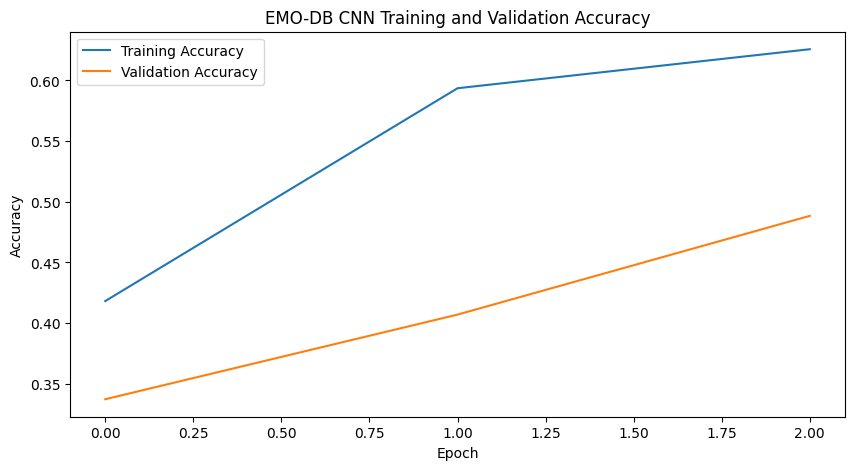

In [ ]:
# Accuracy

plt.figure(figsize=(10, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title(
    'EMO-DB CNN Training and Validation Accuracy'
)

plt.xlabel(
    'Epoch'
)

plt.ylabel(
    'Accuracy'
)

plt.legend()

plt.show()

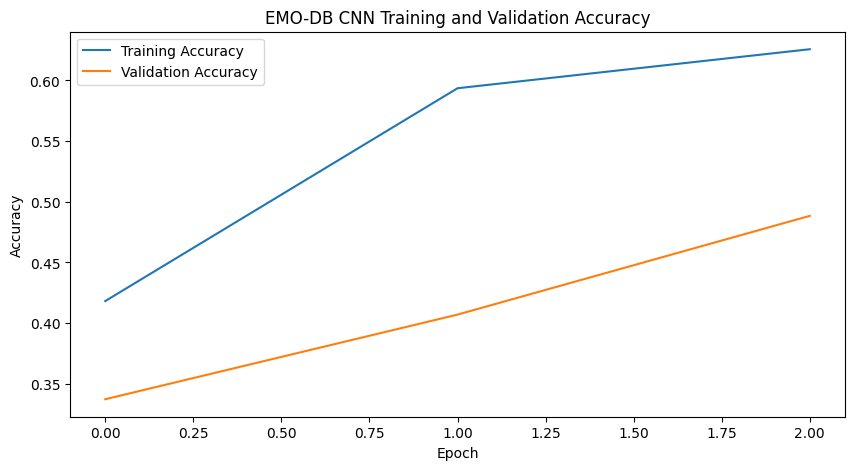

In [ ]:
# Loss

plt.figure(figsize=(10, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title(
    'EMO-DB CNN Training and Validation Accuracy'
)

plt.xlabel(
    'Epoch'
)

plt.ylabel(
    'Accuracy'
)

plt.legend()

plt.show()

In [ ]:
# evaluate

test_loss, test_accuracy = model.evaluate(

    X_test,

    y_test,

    verbose=1
)

print(
    "Test Loss:",
    test_loss
)

print(
    "Test Accuracy:",
    test_accuracy
)

print(
    "Test Accuracy:",
    round(
        test_accuracy * 100,
        2
    ),
    "%"
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.4299 - loss: 1.6935
Test Loss: 1.6935451030731201
Test Accuracy: 0.42990654706954956
Test Accuracy: 42.99 %


In [ ]:
# Make Predictyions

predictions = model.predict(
    X_test
)

predicted_classes = np.argmax(
    predictions,
    axis=1
)

actual_classes = np.argmax(
    y_test,
    axis=1
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


In [ ]:
# Classfication report

print(
    classification_report(

        actual_classes,

        predicted_classes,

        target_names=
        label_encoder.classes_
    )
)

              precision    recall  f1-score   support

       angry       0.49      0.73      0.58        26
     boredom       1.00      0.06      0.12        16
     disgust       0.00      0.00      0.00         9
        fear       0.25      0.07      0.11        14
       happy       0.28      0.57      0.37        14
     neutral       0.55      0.38      0.44        16
         sad       0.85      0.92      0.88        12

    accuracy                           0.43       107
   macro avg       0.49      0.39      0.36       107
weighted avg       0.51      0.43      0.39       107



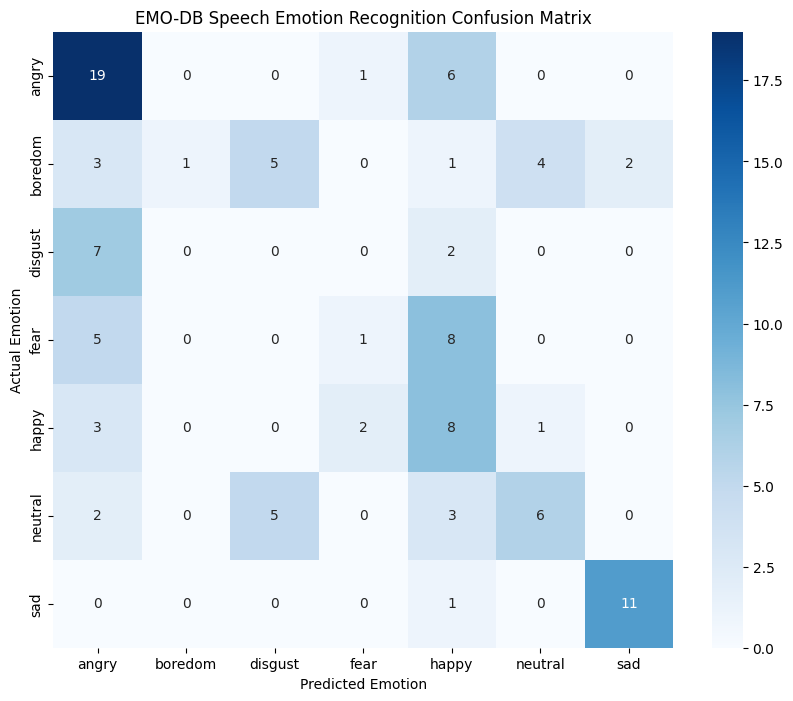

In [ ]:
# Confusion Matrix

cm = confusion_matrix(

    actual_classes,

    predicted_classes
)

plt.figure(figsize=(10, 8))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=
    label_encoder.classes_,

    yticklabels=
    label_encoder.classes_
)

plt.title(
    'EMO-DB Speech Emotion Recognition Confusion Matrix'
)

plt.xlabel(
    'Predicted Emotion'
)

plt.ylabel(
    'Actual Emotion'
)

plt.show()

**Actual** **vs** **Predicted**

In [ ]:
results = pd.DataFrame({

    'Actual Emotion':
        label_encoder.inverse_transform(
            actual_classes
        ),

    'Predicted Emotion':
        label_encoder.inverse_transform(
            predicted_classes
        )
})

display(
    results.head(20)
)

,Actual Emotion,Predicted Emotion
0,disgust,angry
1,fear,angry
2,happy,angry
3,boredom,disgust
4,sad,sad
5,fear,happy
6,neutral,neutral
7,sad,sad
8,neutral,happy
9,boredom,angry


In [ ]:
# Prediction Function

def predict_emotion(
    file_path
):

    mfcc = extract_mfcc(
        file_path
    )

    mfcc = mfcc[
        np.newaxis,
        ...
    ]

    mfcc = mfcc[
        ...,
        np.newaxis
    ]

    prediction = model.predict(
        mfcc,
        verbose=0
    )[0]

    predicted_index = np.argmax(
        prediction
    )

    emotion = label_encoder.classes_[
        predicted_index
    ]

    confidence = prediction[
        predicted_index
    ]

    return emotion, confidence

**Test** **One** **EMO**-**DB** **Audio**

In [ ]:
test_file = emodb_df.iloc[50]['file']

actual_emotion = emodb_df.iloc[50]['emotion']

predicted_emotion, confidence = predict_emotion(
    test_file
)

print(
    "Actual Emotion:",
    actual_emotion
)

print(
    "Predicted Emotion:",
    predicted_emotion
)

print(
    "Confidence:",
    round(
        confidence * 100,
        2
    ),
    "%"
)

Actual Emotion: fear
Predicted Emotion: neutral
Confidence: 27.68 %


In [ ]:
# play the audio

display(
    Audio(test_file)
)

In [ ]:
# savbe the model

model.save(
    "EMODB_Speech_Emotion_CNN.keras"
)

print(
    "EMO-DB CNN model saved successfully!"
)

EMO-DB CNN model saved successfully!


In [ ]:
# save label encoder

with open(
    "emodb_label_encoder.pkl",
    "wb"
) as file:

    pickle.dump(
        label_encoder,
        file
    )

print(
    "Label encoder saved successfully!"
)

Label encoder saved successfully!


# Conclusion :
**Steps Performed**

**Step 1: Dataset Collection**

We used two speech emotion datasets:

RAVDESS – used to recognize 8 emotions: Neutral, Calm, Happy, Sad, Angry, Fearful, Disgust, and Surprised.
EMO-DB – used to recognize 7 emotions: Angry, Boredom, Disgust, Fear, Happy, Neutral, and Sad.


**Step 2: Data Understanding**

The audio files were analyzed and the emotion labels were obtained from the file names. Since RAVDESS and EMO-DB use different filename formats and emotion codes, separate mappings were created for both datasets.

**Step 3: Audio Preprocessing**

The audio files were loaded using Librosa. The recordings were converted to a common sampling rate and processed into a consistent format.

Shorter audio feature sequences were padded, while longer sequences were truncated so that all inputs had the same dimensions.

**Step 4: Feature Extraction**

MFCC (Mel-Frequency Cepstral Coefficients) features were extracted from every audio recording.

MFCC converts the speech signal into useful numerical features that represent important characteristics of human speech.

In our implementation:

40 MFCC coefficients were extracted and converted into a fixed-size feature matrix.

**Step 5: Data Preparation**

The extracted MFCC features were converted into NumPy arrays.

The emotion labels were converted into numerical values using LabelEncoder and then one-hot encoded for multi-class classification.

The data was divided into:

80% Training Data
20% Testing Data
**Step 6: CNN Model Building**

A Convolutional Neural Network (CNN) was developed for emotion classification.

The model contains:

Convolutional layers
Batch Normalization
Max Pooling
Flatten layer
Dense layers
Dropout
Softmax output layer

The CNN learns important patterns from the MFCC features and associates those patterns with different emotions.

**Step 7: Model Training**

The CNN was trained using the training dataset.

During training, the model learned the relationship between:

Speech Features → Emotional State

Validation data was used to monitor the model's performance, and Early Stopping was used to reduce overfitting.

**Step 8: Model Evaluation**

After training, the model was tested using previously unseen test data.

The following metrics were used:

Accuracy – overall correct predictions
Precision – correctness of predicted emotions
Recall – ability to identify actual emotions
F1-score – balance between precision and recall
Confusion Matrix – shows correct and incorrect predictions for each emotion

**Step 9: Emotion Prediction**

For a new audio recording, the system follows:

New Audio → Preprocessing → MFCC Extraction → CNN → Emotion Probabilities → Highest Probability → Final Emotion

For example:

Input Audio
     ↓
MFCC Features
     ↓
CNN Model
     ↓
Angry      5%
Happy     82%
Sad        7%
Neutral    6%
     ↓
Predicted Emotion = Happy

The model can also provide a confidence score for the predicted emotion.

**Step 10: Comparison of RAVDESS and EMO-DB**

Feature	RAVDESS	EMO-DB
Type	Speech & Song	Speech
Emotions Used	8	7
Feature	MFCC	MFCC
Model	CNN	CNN
Label Source	Filename	Filename
Prediction	Emotion + Confidence	Emotion + Confidence

**Conclusion :**

We successfully developed a Speech Emotion Recognition system using RAVDESS and EMO-DB datasets. The project started with collecting and understanding the audio data, followed by audio preprocessing and MFCC feature extraction. The extracted speech features were then given to a Convolutional Neural Network (CNN) for emotion classification.

The RAVDESS model was designed to recognize 8 emotions, while the EMO-DB model recognized 7 emotions. Since both datasets have different emotion labels and filename structures, separate label mappings were used for each dataset.

The trained models were evaluated using accuracy, precision, recall, F1-score, and confusion matrix. Finally, new audio recordings were passed through the same preprocessing and MFCC extraction process, after which the CNN predicted the most likely emotion along with its confidence.

Overall, this task helped us understand the complete workflow of Speech Emotion Recognition—from raw audio processing and feature extraction to CNN training, evaluation, and final emotion prediction. It also demonstrated how deep learning can be used in real-world applications such as customer service, virtual assistants, call-center analysis, and human-computer interaction.